Purpose: Plot profiles for each CAM gene family in each parental species.<br>
Author: Anna Pardo<br>
Date initiated: Mar. 9, 2026

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
# load TPM for each parent
yatpm = pd.read_csv("/home/leviathan22/Yucca_genomics/rna_reanalysis_30-Jun-2025/TPM/Yalo_TPM_withmd_July2025.txt",
                    sep="\t",header="infer")

In [3]:
yftpm = pd.read_csv("/home/leviathan22/Yucca_genomics/rna_reanalysis_30-Jun-2025/TPM/YfilH1_TPM_withmd_July2025.txt",
                   sep="\t",header="infer")

In [4]:
# load CAM annotation
cam = pd.read_csv("/home/leviathan22/Yucca_genomics/rna_insilico_genome/degs_downstream/camgenes_Ya_Yf_orthology_synteny.txt",
                 sep="\t",header="infer")

In [5]:
cam.head()

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr,gene_abbr_unique,subgenome
0,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya
1,Yucal.02G112700.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_2,Ya
2,Yucal.04G001000.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_1,Ya
3,Yucal.07G000800.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_2,Ya
4,Yucal.03G120900.v2.1,OG0002899,CAM-dark,NAD-dependent malate dehydrogenase (chloroplas...,NAD-MDH-cp,Ya_NAD-MDH-cp_1,Ya


In [104]:
# reworked plot_profile() function - to plot profiles by subgenome as well as treatment
def plot_profile(fam,cpdf,axc,a,tf,titletext="Gene Family: ",log=False):
    # where axc=either a single value or a tuple
    t = np.arange(0,25)
    xthresh = 12
    
    # convert to logTPM if log=True
    if log==True:
        cpdf["logTPM"] = np.log1p(cpdf["TPM"])
        sns.lineplot(ax=a[axc],data=cpdf,x="ZT",y="logTPM",hue="treat")
    else:
        sns.lineplot(ax=a[axc],data=cpdf,x="ZT",y="TPM",hue="treat")
    
    #lim = a[axc].get_ylim()[1]
    a[axc].fill_between(t,0,1,where=t>=xthresh,color="gray",alpha=0.3,transform=a[axc].get_xaxis_transform())
    #a[axc].set_ylim(0,lim)
    
    a[axc].set_xlim(0,24)
    a[axc].tick_params(axis="both",which="major",labelsize=16)
    a[axc].set_xticks(ticks=list(cpdf["ZT"].unique()))
    a[axc].set_xlabel("")
    a[axc].set_ylabel("TPM from uniquely mapped reads",fontsize=16)
    a[axc].set_title(titletext+fam,fontsize=tf)

In [59]:
# rework plottpm similarly
def plottpm_genefamily(tpm,genefam,camdf=cam):
    camfam = camdf[camdf["gene_abbr"]==genefam]
    csgd = {}
    for i in range(len(camfam.index)):
        csgd[camfam.iloc[i,0]] = camfam.iloc[i,6]
    cgenes = [i for i in list(camfam["GeneID"].unique()) if i in tpm.columns]
    cols = ["sample_name","genotype","treat","ZT"]+cgenes
    pwide = tpm[cols]
    plong = pd.melt(pwide,id_vars=["sample_name","genotype","treat","ZT"],value_vars=cgenes)
    plong = plong.rename(columns={"variable":"GeneID","value":"TPM"}).sort_values(by="treat",ascending=False)
    return plong.sort_values(by=["treat"],ascending=False)

In [105]:
def plot_genefam_bothsp(genefam, outdir):
    yagf = plottpm_genefamily(yatpm, genefam)
    yfgf = plottpm_genefamily(yftpm, genefam)
    
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20,10), sharey=False)

    plot_profile("", yfgf, 1, ax, 20, "Y. filamentosa (C3)")
    plot_profile("", yagf, 0, ax, 20, "Y. aloifolia (CAM)")

    # sync to max ylim 
    ylims = [a.get_ylim()[1] for a in ax]
    ymax = max(ylims)
    for a in ax:
        a.set_ylim(0, ymax)

    plt.suptitle(genefam + " Parental Expression Profiles", fontsize=24)
    fig.tight_layout()

    plt.savefig(os.path.join(outdir, genefam+"_parental_profiles.png"), dpi=200, bbox_inches="tight")
    plt.savefig(os.path.join(outdir, genefam+"_parental_profiles.pdf"), dpi=200, bbox_inches="tight")
    plt.savefig(os.path.join(outdir, genefam+"_parental_profiles.svg"), dpi=200, bbox_inches="tight")

In [68]:
d = "./parental_CAM_profiles/"

In [69]:
cam.head()

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr,gene_abbr_unique,subgenome
0,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya
1,Yucal.02G112700.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_2,Ya
2,Yucal.04G001000.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_1,Ya
3,Yucal.07G000800.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_2,Ya
4,Yucal.03G120900.v2.1,OG0002899,CAM-dark,NAD-dependent malate dehydrogenase (chloroplas...,NAD-MDH-cp,Ya_NAD-MDH-cp_1,Ya


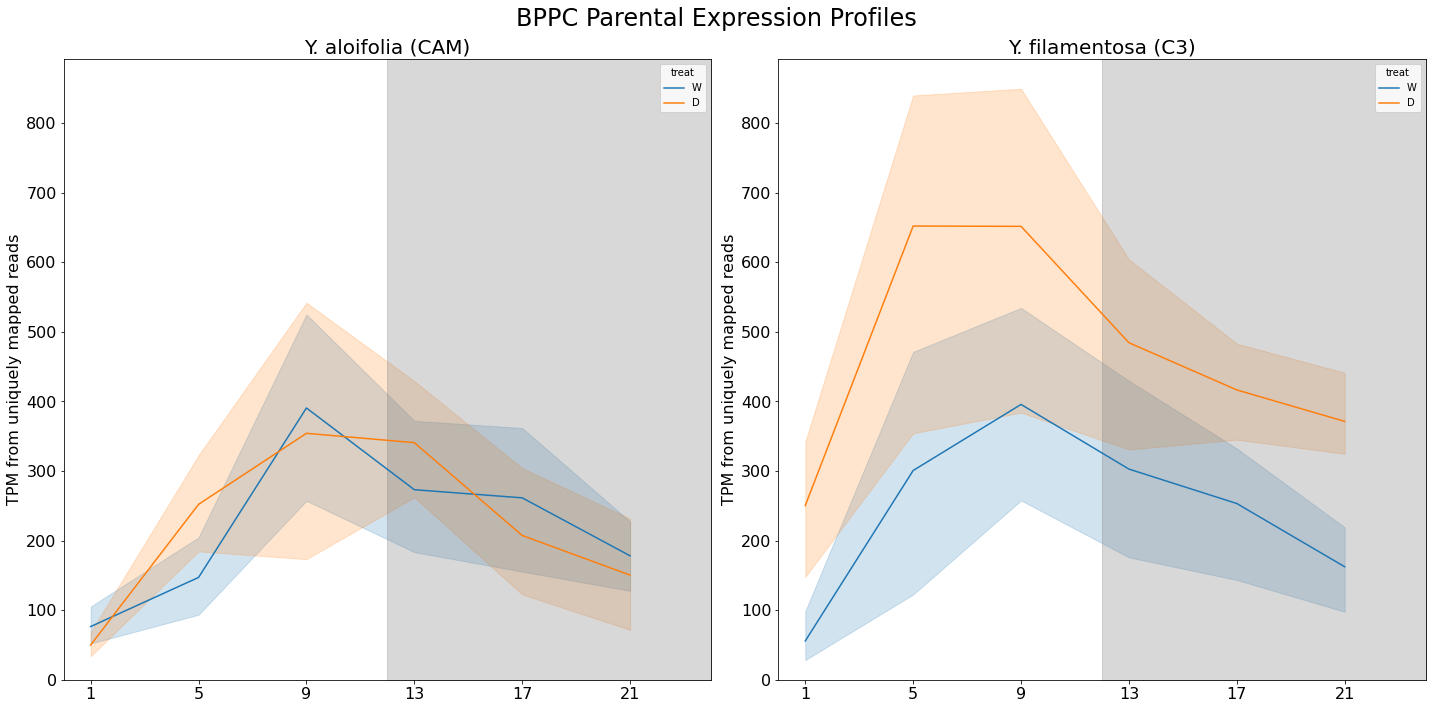

In [106]:
plot_genefam_bothsp("BPPC",d)

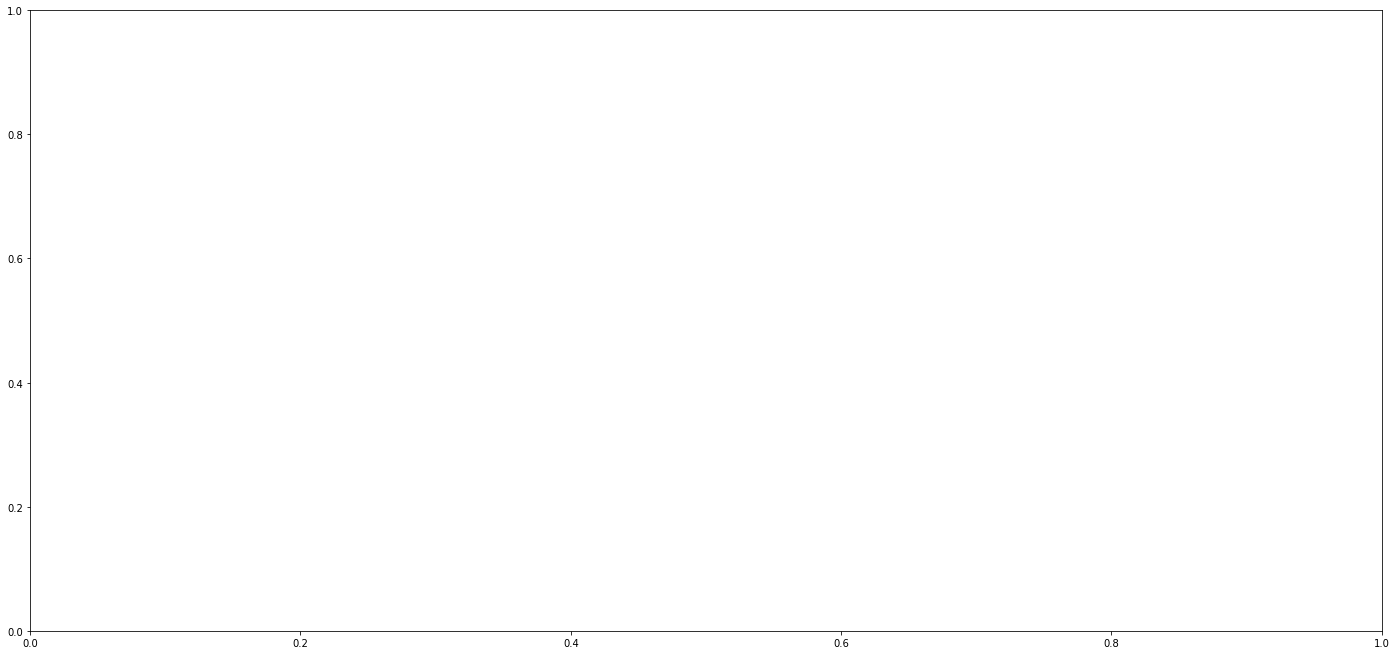

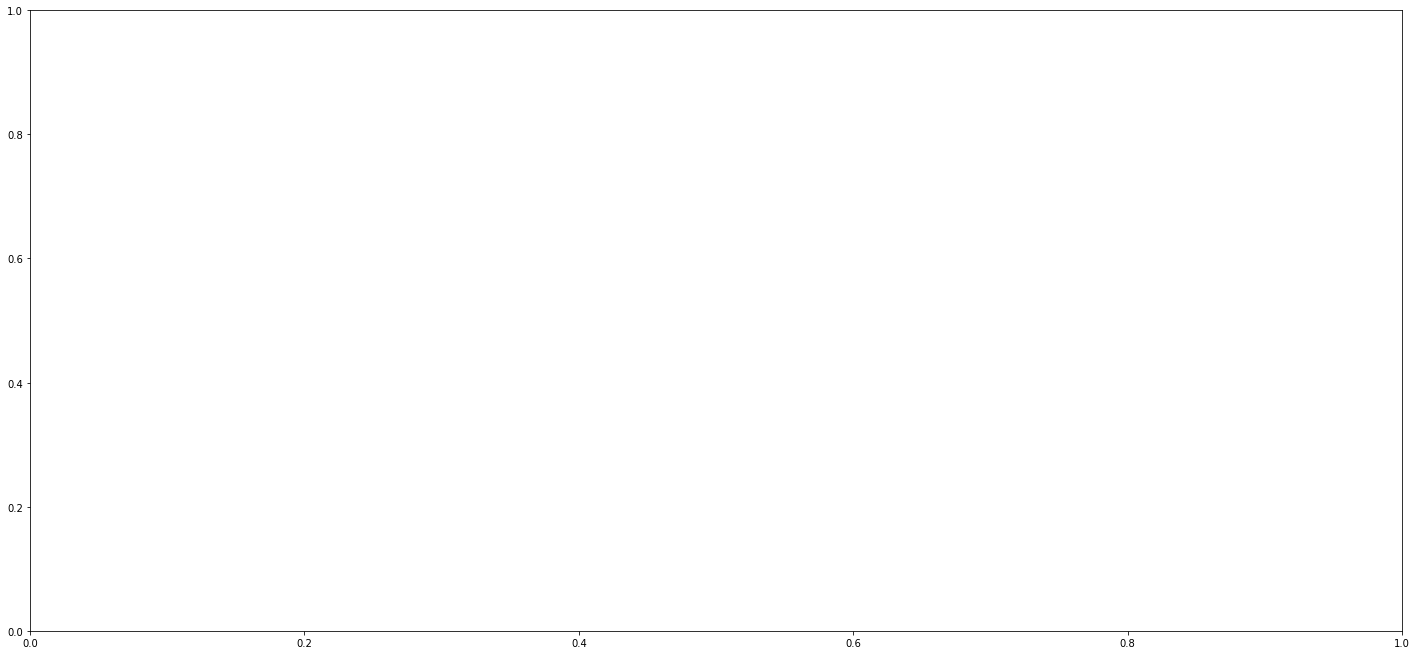

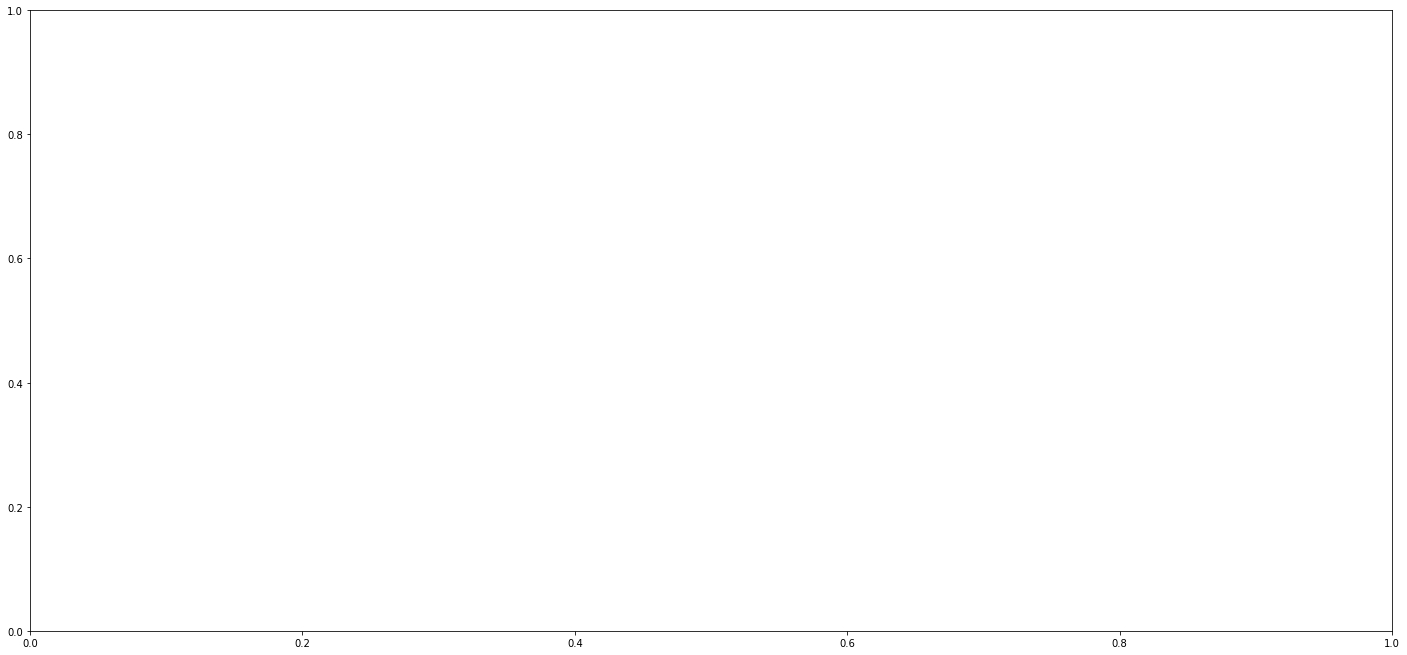

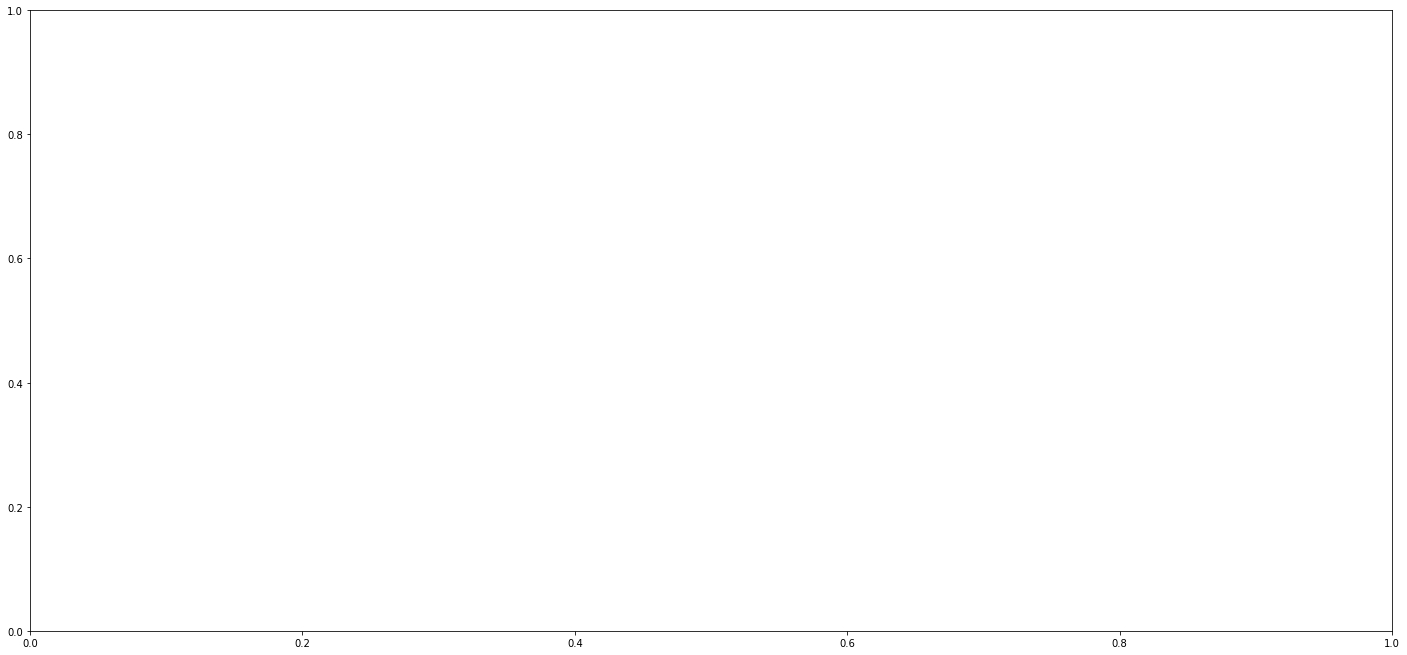

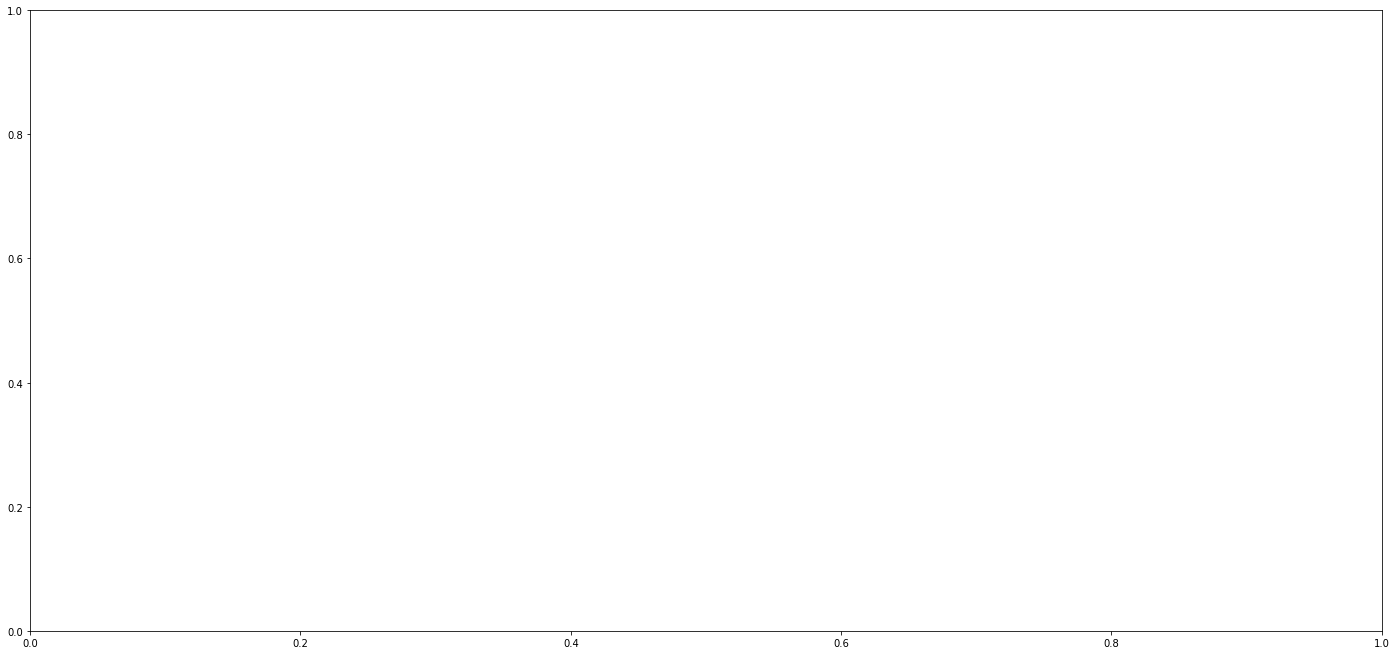

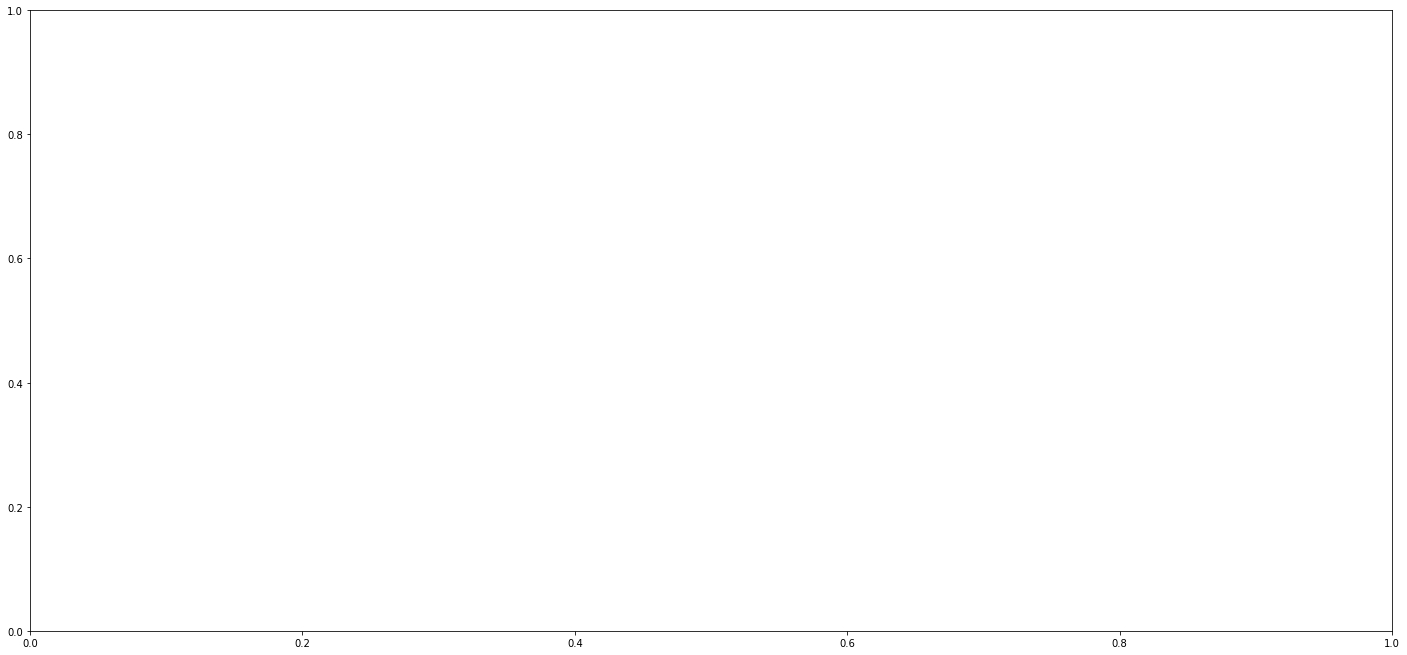

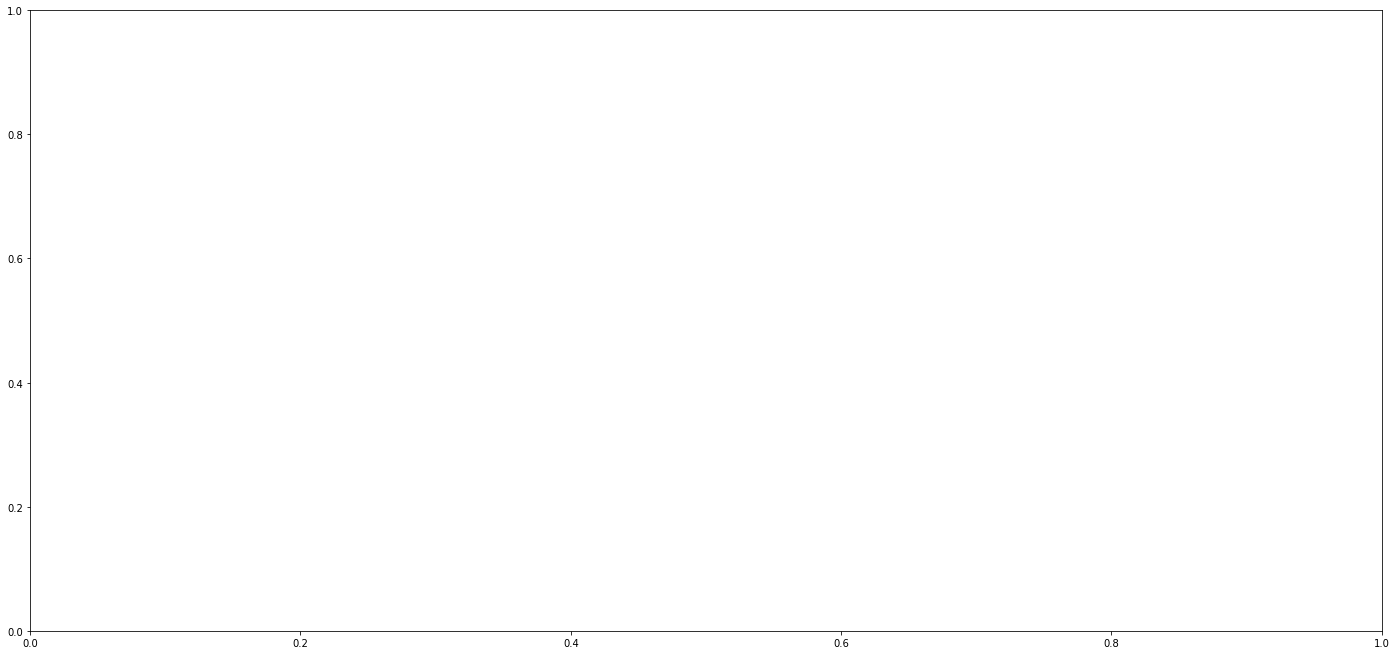

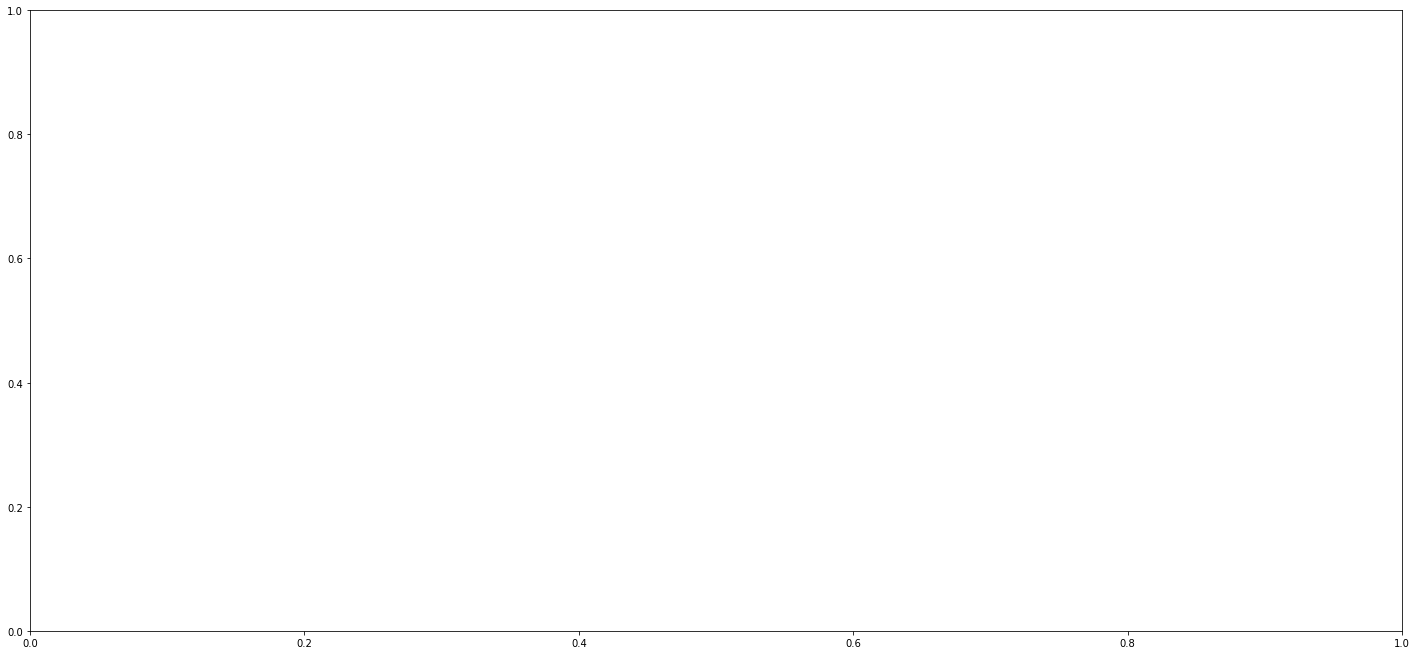

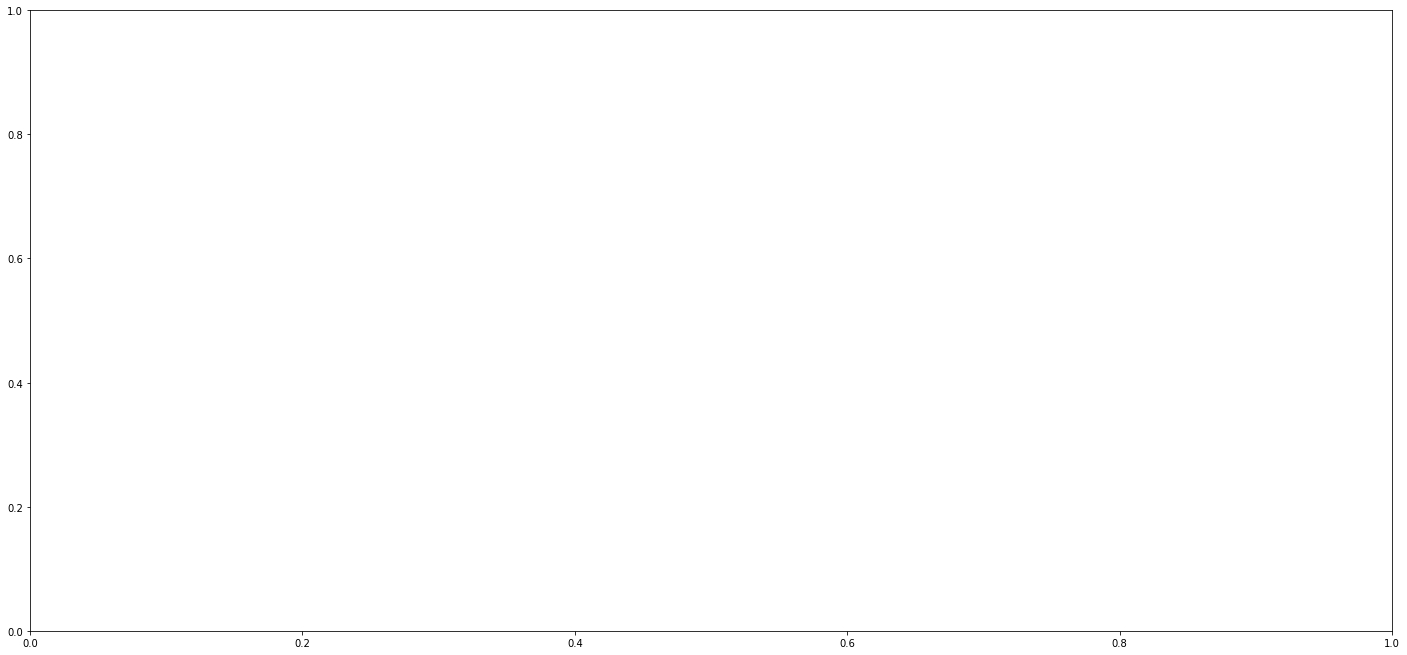

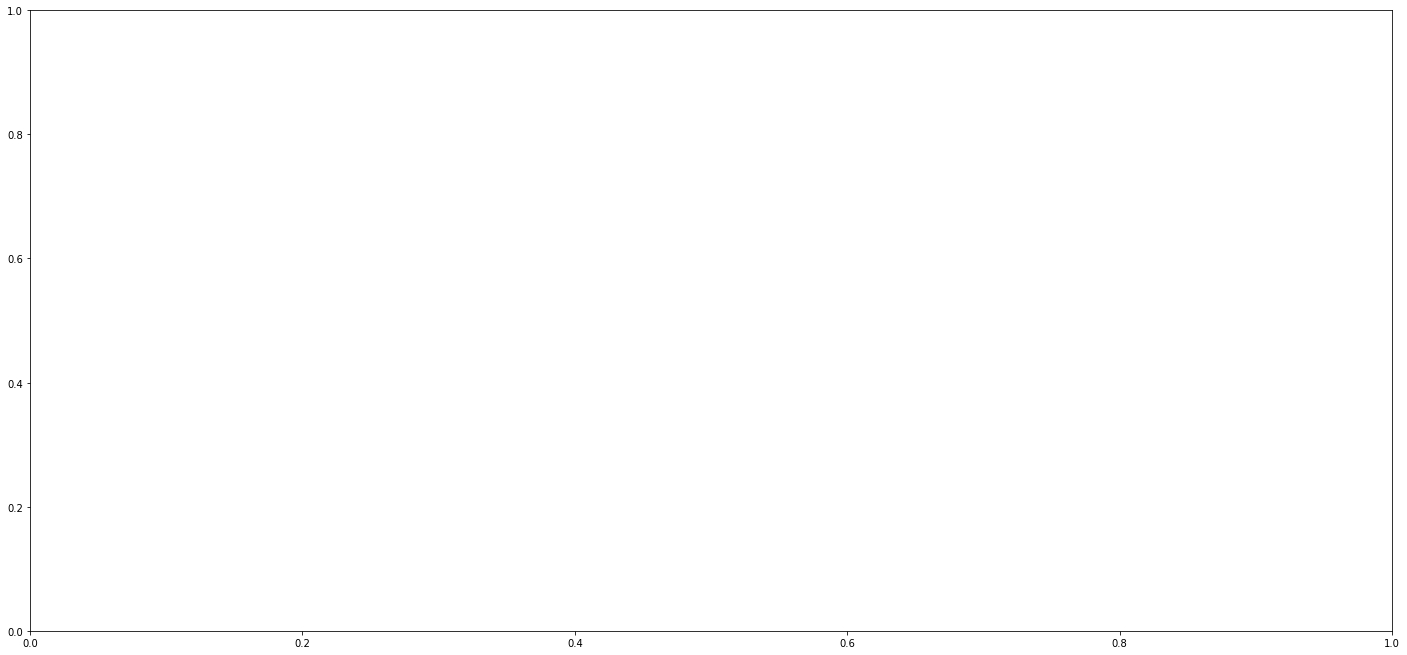

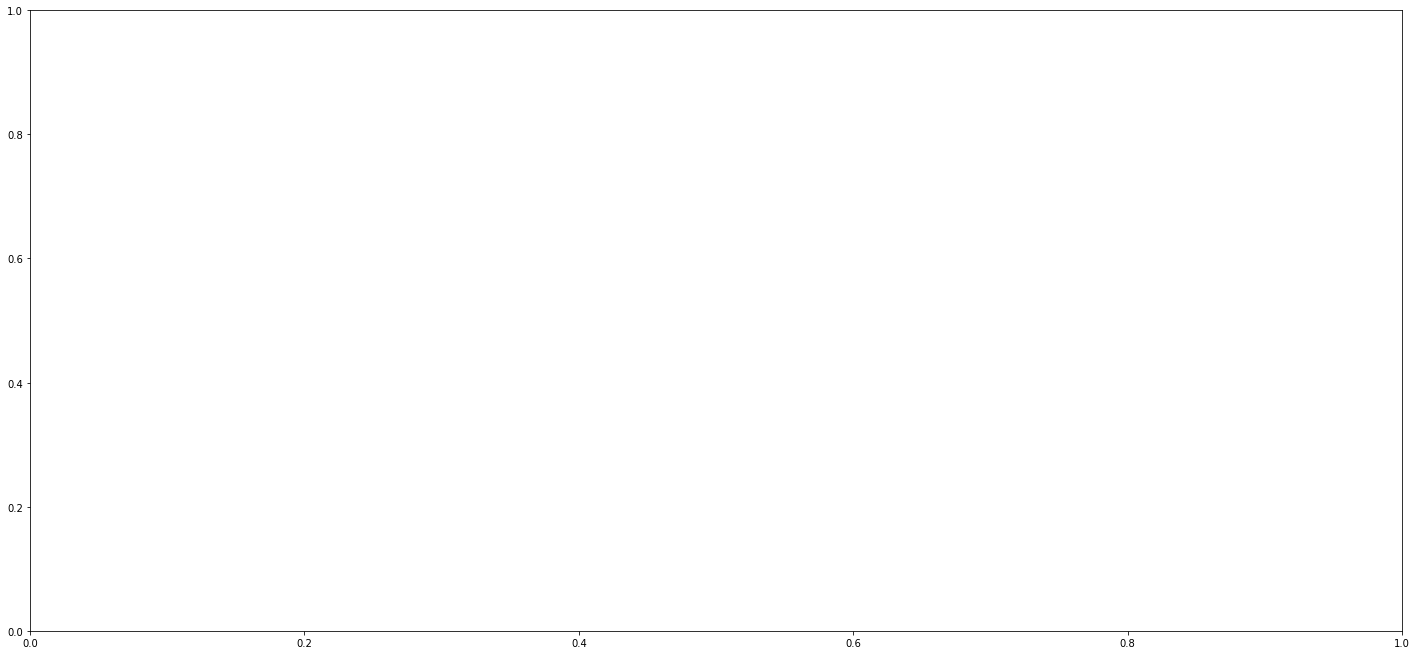

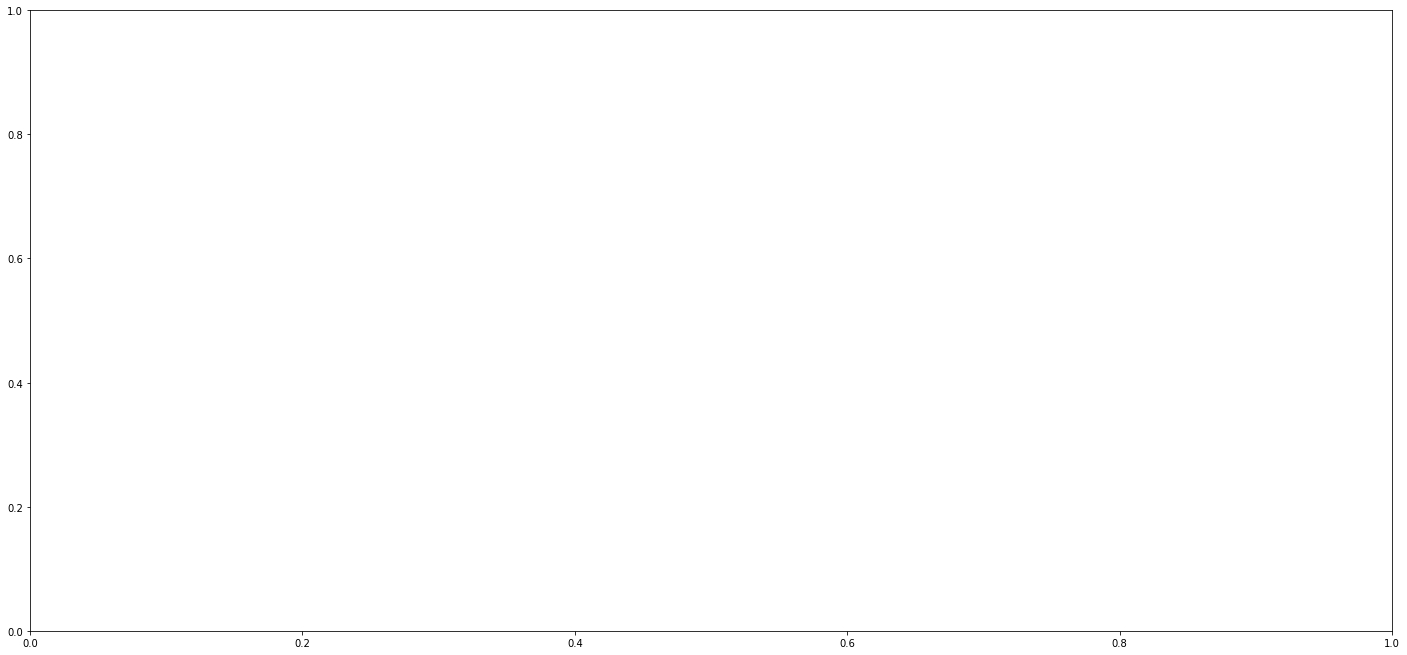

In [107]:
for i in cam["gene_abbr"].unique():
    plot_genefam_bothsp(i,d)
    plt.clf()
    plt.cla()